# 03 — Item-Based Collaborative Filtering

**Hour 2, 95–112 min: Comparing movies instead of users**

Instead of asking "which USERS are similar?", we now ask "which ITEMS (movies) are similar,
based on how users rated them?" The mechanics are almost identical to Notebook 02 — we're just
comparing along the other axis of the same matrix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 5.5)

ratings = pd.read_csv("../data/movie_ratings_dataset.csv")
user_item_matrix = ratings.pivot_table(index="user_id", columns="movie_title", values="rating")
user_item_filled = user_item_matrix.fillna(0)

genre_lookup = ratings.drop_duplicates("movie_title").set_index("movie_title")["genre"]
user_item_matrix.shape

(300, 60)

## Step 1 — Create the Item-User Matrix

**What are we doing?** We already have the user-item matrix — for item-based similarity we
simply compare its COLUMNS instead of its rows. Transposing the matrix (`.T`) makes each
movie a row, which is what `cosine_similarity()` expects to compare.

In [2]:
item_user_matrix = user_item_filled.T   # movies become rows, users become columns
item_user_matrix.iloc[:6, :5]

user_id,U100,U101,U102,U103,U104
movie_title,,,,,
A Winter's Promise,2.0,0.0,0.0,5.0,0.0
Apex Strike,0.0,0.0,0.0,4.0,2.0
Autumn in Paris,0.0,3.0,0.0,0.0,0.0
Beyond the Rift,0.0,0.0,4.0,0.0,0.0
Blackout Squad,4.0,0.0,3.0,4.0,0.0
Blind Date Bingo,0.0,0.0,0.0,0.0,4.0


## Step 2 — Calculate Item Similarity

**What does this compare?** Two movies are considered similar if they tend to be rated
similarly BY THE SAME USERS — not because of their plot, actors, or description.

In [3]:
item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index,
)

item_similarity_df.iloc[:5, :5].round(2)

movie_title,A Winter's Promise,Apex Strike,Autumn in Paris,Beyond the Rift,Blackout Squad
movie_title,,,,,
A Winter's Promise,1.00,0.15,0.15,0.19,0.19
Apex Strike,0.15,1.00,0.10,0.07,0.69
Autumn in Paris,0.15,0.10,1.00,0.12,0.05
Beyond the Rift,0.19,0.07,0.12,1.00,0.11
Blackout Squad,0.19,0.69,0.05,0.11,1.00


## Step 3 — Find Movies Similar to a Given Movie

In [4]:
target_movie = "Steel Vendetta"

similar_movies = (
    item_similarity_df[target_movie]
    .drop(target_movie)
    .sort_values(ascending=False)
    .head(8)
)

sim_table = pd.DataFrame({
    "similarity": similar_movies.round(2),
    "genre": genre_lookup.reindex(similar_movies.index),
})
print(f"Target movie: {target_movie} ({genre_lookup[target_movie]})")
sim_table

Target movie: Steel Vendetta (Action)


,similarity,genre
movie_title,,
Crimson Velocity,0.69,Action
Apex Strike,0.65,Action
Ghost Payload,0.64,Action
Midnight Pursuit,0.61,Action
Last Stand Alpha,0.60,Action
Blackout Squad,0.60,Action
Titan Fall Zero,0.59,Action
Rogue Circuit,0.58,Action


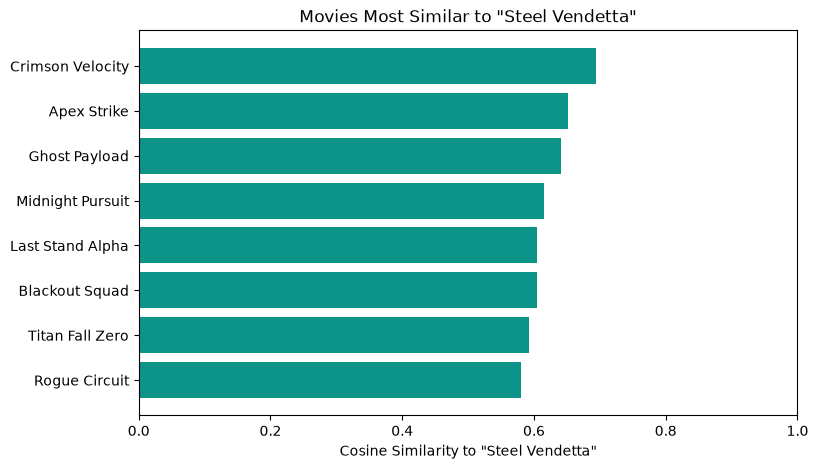

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(similar_movies.index[::-1], similar_movies.values[::-1], color="#0D9488")
ax.set_xlabel(f'Cosine Similarity to "{target_movie}"')
ax.set_title(f'Movies Most Similar to "{target_movie}"')
ax.set_xlim(0, 1)
plt.show()

**Sanity check:** notice nearly every similar movie shares the SAME genre as the target movie, even though genre was never used in the similarity calculation — it emerged purely from co-rating patterns. This is a strong signal our approach is working correctly.

## Step 4 — Generate Item-Based Recommendations

Workflow from the slides:

```
Item → Find Similar Items → Look at User History → Find Items Matching User History → Recommend
```

In [6]:
def recommend_similar_movies(movie_title, top_n=5):
    """
    Recommends movies similar to `movie_title`, based on item-based collaborative filtering.
    """
    similar = (
        item_similarity_df[movie_title]
        .drop(movie_title)
        .sort_values(ascending=False)
        .head(top_n)
    )
    return similar


recs = recommend_similar_movies("Steel Vendetta", top_n=5)
print(f'Because you liked "Steel Vendetta":\n')
for i, (movie, score) in enumerate(recs.items(), start=1):
    print(f"{i}. {movie}  (similarity: {score:.2f}, genre: {genre_lookup[movie]})")

Because you liked "Steel Vendetta":

1. Crimson Velocity  (similarity: 0.69, genre: Action)
2. Apex Strike  (similarity: 0.65, genre: Action)
3. Ghost Payload  (similarity: 0.64, genre: Action)
4. Midnight Pursuit  (similarity: 0.61, genre: Action)
5. Last Stand Alpha  (similarity: 0.60, genre: Action)


## Step 5 — Recommend for a User Based on Their History

A more complete item-based recommender looks at EVERYTHING a user has rated highly, and
aggregates similar-item scores across all of them — not just one movie.

In [7]:
def recommend_movies_item_based(user_id, top_n=5, liked_threshold=4):
    """
    Recommends movies for `user_id` using item-based collaborative filtering:
    for every movie the user rated highly, find similar movies, and aggregate.
    """
    user_ratings = user_item_matrix.loc[user_id].dropna()
    liked_movies = user_ratings[user_ratings >= liked_threshold].index
    already_rated = user_ratings.index

    scores = pd.Series(dtype=float)
    for movie in liked_movies:
        sims = item_similarity_df[movie].drop(movie, errors="ignore")
        for other_movie, sim_score in sims.items():
            if other_movie in already_rated:
                continue
            scores[other_movie] = scores.get(other_movie, 0) + sim_score

    return scores.sort_values(ascending=False).head(top_n)


item_based_recs = recommend_movies_item_based("U100", top_n=5)
rec_table = pd.DataFrame({
    "score": item_based_recs.round(2),
    "genre": genre_lookup.reindex(item_based_recs.index),
})
rec_table

,score,genre
Apex Strike,4.57,Action
Crimson Velocity,4.46,Action
Iron Protocol,3.74,Action
Whispers in the Attic,1.29,Horror
The Weight of Silence,1.14,Drama


### Recap
- We compared MOVIES instead of users, by transposing the user-item matrix.
- Item similarity picked out genre-coherent neighbours, purely from co-rating patterns.
- We built two functions: `recommend_similar_movies()` (movie → similar movies) and
  `recommend_movies_item_based(user_id)` (user → recommendations, aggregated across everything
  they liked).

**Next: `04_Collaborative_Filtering_Mini_Project.ipynb`** — comparing both approaches side by
side, a basic evaluation, and the mini challenge.